#  **Superstore Sales Data Analysis**

**Dataset:** Superstore Sales Dataset

**Tools & Technologies:** Python, Numpy, Pandas, Matplotlib, Seaborn


## **Project Objective**

The objective of this project is to analyze the Superstore sales dataset using Python to identify sales trends, business performance, customer behavior and profitability. The analysis aims to generate actionable insights through data cleaning, exploratory data analysis (EDA) and data visualization.

In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

Dataset contain 9994 rows and 21 columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### Observation

The initial dataset structure was examined to understand the number of records, available features and data types before performing data cleaning.

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Missing values were identified to ensure data completeness before analysis.

In [8]:
df.duplicated().sum()

np.int64(0)

Duplicate records were checked and removed to prevent inaccurate analytical results.

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

The Order Date column was converted into datetime format for time-based analysis.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

All columns were verified to ensure they have appropriate data types for analysis.

In [11]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [12]:
df['Region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [13]:
df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [14]:
df.to_csv('Superstore_Cleaned.csv', index=False)

## **Data Cleaning**

The dataset was cleaned by handling missing values, removing duplicate records, correcting data types and preparing the data for accurate analysis.

## **Exploratory Data Analysis (EDA)**

EDA was performed to uncover sales trends, profitability, regional performance and other key business insights using statistical summaries and visualizations.

**What is the Total Sales Generated by the Superstore?**

In [15]:
total_sales = df['Sales'].sum()
print("Total Sales:", round(total_sales, 2))

Total Sales: 2297200.86


### Observation
The Superstore generated total sales of $2.30 million during the analysis period, indicating a strong overall revenue performance across all products and regions.

### Business Insight

The total sales value provides a high-level overview of business performance and serves as a benchmark for comparing other key performance metrics such as profit, regional sales, and category performance.

**What is the Total Profit Earned by the Superstore?**

In [16]:
total_profit = df['Profit'].sum()
print(f"Total Profit : {total_profit:,.2f}")

Total Profit : 286,397.02


### Observation

The Superstore earned a total profit of approximately $286K, indicating that the business remained profitable throughout the analysis period.

### Business Insight

Comparing total profit with total sales helps evaluate the overall financial performance of the business and provides a foundation for profitability analysis.

**How Many Unique Orders Were Placed?**

In [17]:
# Calculate Total Orders

total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


### Observation

A total of 5,009 unique orders were placed during the analysis period. This indicates a healthy volume of customer transactions and reflects the overall business activity.

### Business Insight

The total number of orders helps evaluate customer demand and serves as a key metric for calculating the average order value and measuring business growth.

**What is the Average Order Value (AOV)?**

In [18]:
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()

average_order_value = total_sales / total_orders

print("Average Order Value (AOV):", round(average_order_value, 2))

Average Order Value (AOV): 458.61


### Observation

The average order value is $458.61, indicating the average amount spent by customers per order. This metric helps understand customer purchasing behavior and overall revenue generation.

### Business Insight

Increasing the average order value through product bundling, cross-selling or promotional offers can help improve total revenue without increasing the number of customer orders.

**How Sales Changed Over Time? (Monthly Sales Trend)**

In [19]:
# Create Year and Month columns

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

# Create Year-Month column for chronological analysis

df['Year_Month'] = df['Order Date'].dt.to_period('M')

In [20]:
monthly_sales = df.groupby('Year_Month')['Sales'].sum().reset_index()

monthly_sales

,Year_Month,Sales
0,2014-01,14236.8950
1,2014-02,4519.8920
2,2014-03,55691.0090
3,2014-04,28295.3450
4,2014-05,23648.2870
5,2014-06,34595.1276
6,2014-07,33946.3930
7,2014-08,27909.4685
8,2014-09,81777.3508
9,2014-10,31453.3930


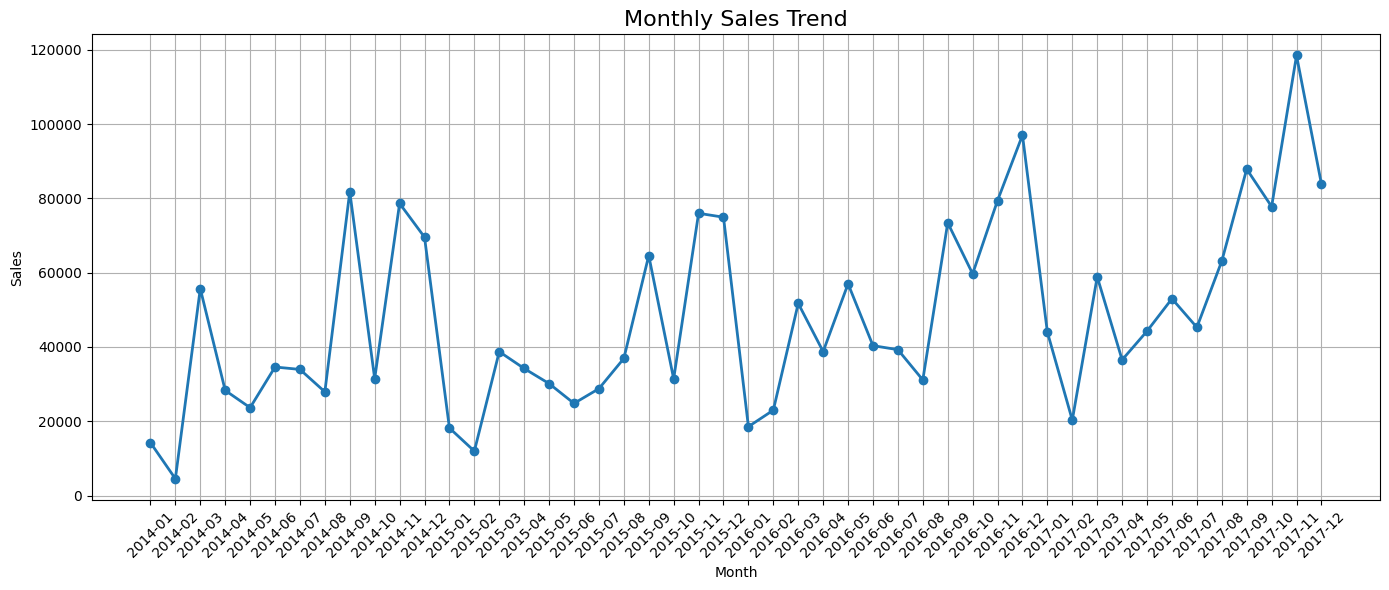

In [21]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales['Year_Month'].astype(str),
    monthly_sales['Sales'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

Monthly sales fluctuate throughout the analysis period, showing periods of growth and decline. Overall, the business demonstrates a stable sales trend with noticeable seasonal variations in customer demand.

### Business Insight

Monitoring monthly sales trends helps identify seasonal demand patterns, evaluate business performance over time and support better sales forecasting and inventory planning.

**Which Product Categories Generate the Highest Sales?**

In [22]:
# Calculate Top 10 Products by Sales

top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [23]:
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales['Sales Percentage'] = (
    category_sales['Sales'] /
    category_sales['Sales'].sum()
) * 100

category_sales

,Category,Sales,Sales Percentage
0,Technology,836154.0330,36.398821
1,Furniture,741999.7953,32.300171
2,Office Supplies,719047.0320,31.301008


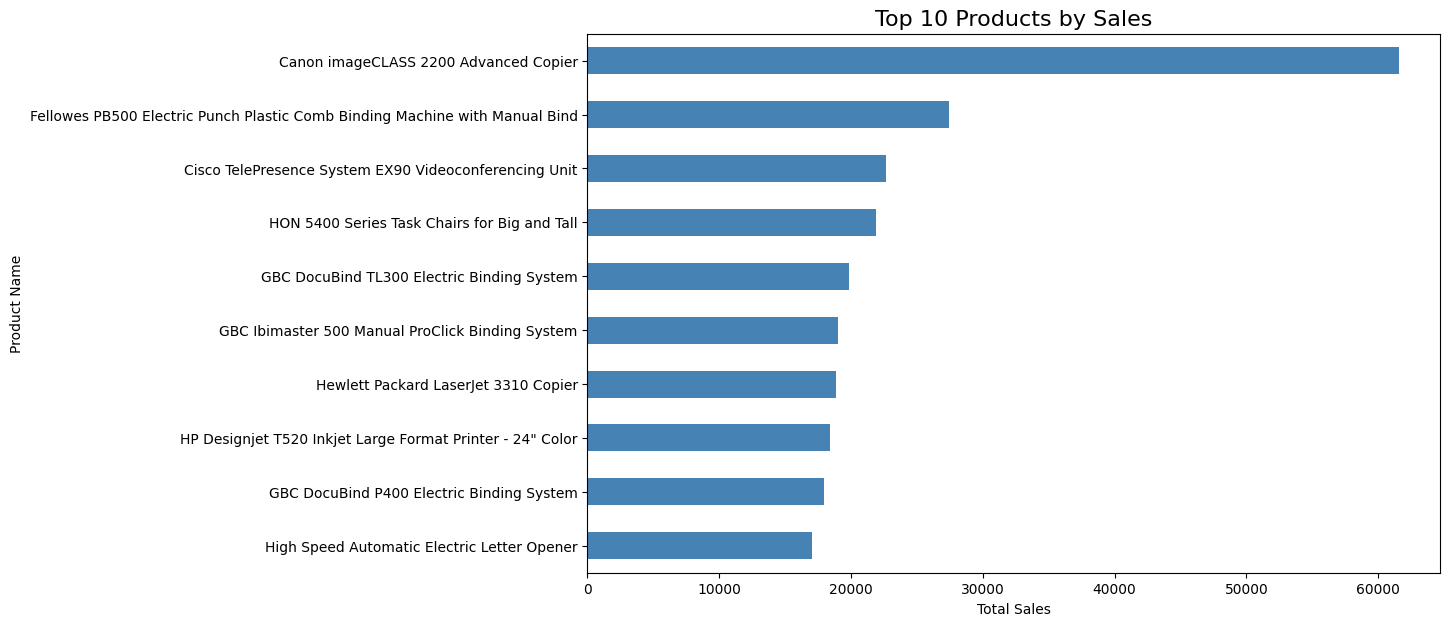

In [24]:
plt.figure(figsize=(11,7))

top_products.plot(
    kind='barh',
    color='steelblue'
)

plt.title('Top 10 Products by Sales', fontsize=16)
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()

plt.show()

### Observation

Technology is the highest-performing product category, contributing the largest share of total sales. This suggests that customer demand is strongest for technology products, making this category a key driver of business revenue.


### Business Insight

The company should continue investing in high-performing technology products while identifying strategies to improve the sales of lower-performing categories through targeted promotions and product optimization.

**Which Products Generate the Lowest Sales Revenue? (Bottom 10 Products)**

In [25]:
# Calculate Bottom 10 Products by Sales

bottom_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

bottom_products

,Sales
Product Name,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624
Avery 5,5.760
Xerox 20,6.480
Grip Seal Envelopes,7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800
Xerox 1989,7.968
4009 Highlighters,8.040
Stockwell Gold Paper Clips,8.096


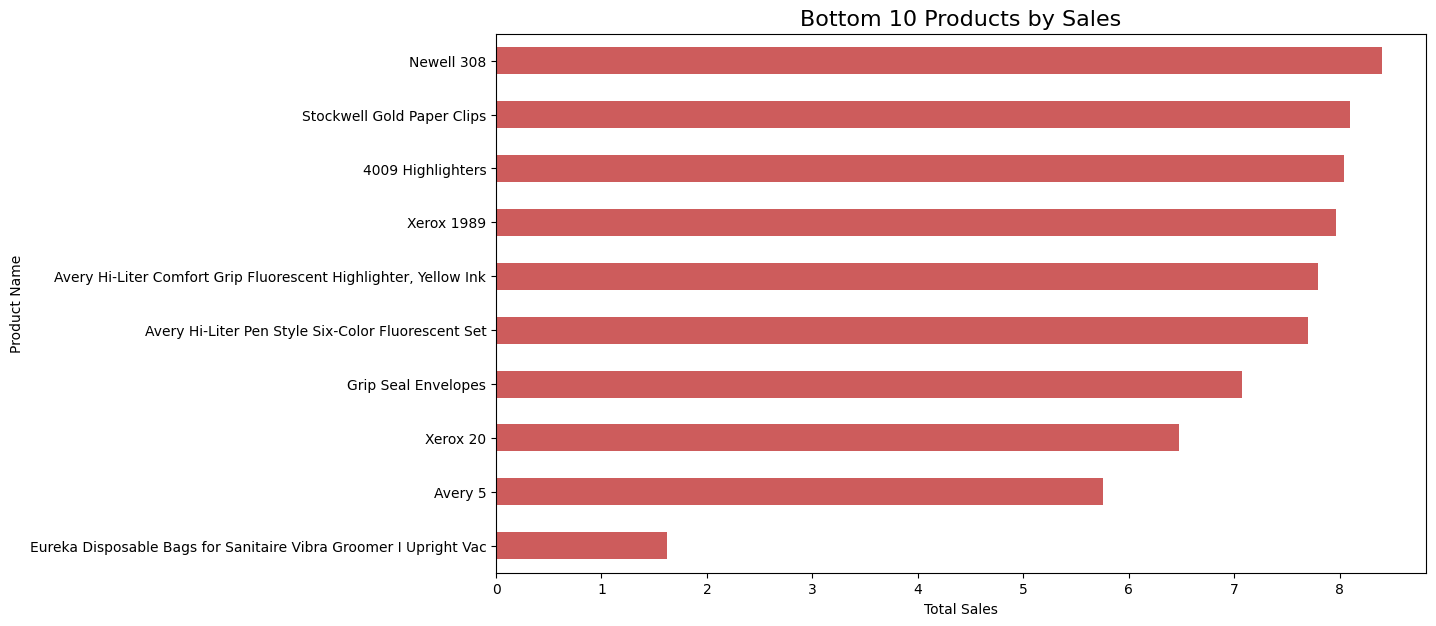

In [26]:
plt.figure(figsize=(12,7))

bottom_products.plot(
    kind='barh',
    color='indianred'
)

plt.title('Bottom 10 Products by Sales', fontsize=16)
plt.xlabel('Total Sales')
plt.ylabel('Product Name')

plt.show()

### Observation

The bottom 10 products generated the lowest sales revenue among all products. These products contribute only a small portion of total sales, indicating low customer demand or limited market performance.




### Business Insight

The company should review the pricing, marketing strategy and customer demand for these low-performing products. If these products continue to underperform, inventory optimization or product portfolio adjustments may help improve overall business performance.

**Which Product Categories Generate the Highest Sales?**

In [27]:
# Sales by Category
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Add Sales Contribution (%)
category_sales['Sales Contribution (%)'] = (
    category_sales['Sales'] / category_sales['Sales'].sum() * 100
).round(2)

category_sales

,Category,Sales,Sales Contribution (%)
0,Technology,836154.0330,36.4
1,Furniture,741999.7953,32.3
2,Office Supplies,719047.0320,31.3


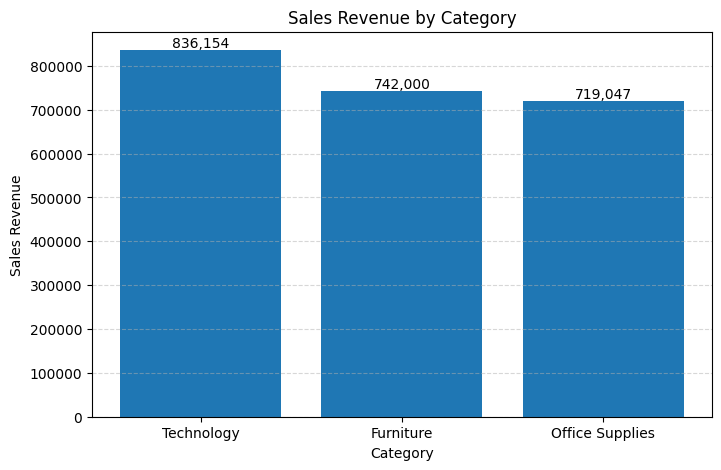

In [28]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    category_sales['Category'],
    category_sales['Sales']
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Sales Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Sales Revenue')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

Technology generated the highest sales revenue among all product categories, followed by Furniture and Office Supplies. This indicates that technology products are the primary drivers of the company's overall sales performance.

### Business Insight

The company should continue investing in the Technology category while implementing targeted marketing and promotional strategies to improve sales in the lower-performing categories.

**Which Region Generates the Highest Sales Revenue?**

In [29]:
# Sales by Region
region_sales = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Add Sales Contribution (%)
region_sales['Sales Contribution (%)'] = (
    region_sales['Sales'] / region_sales['Sales'].sum() * 100
).round(2)

# Display the table
region_sales

,Region,Sales,Sales Contribution (%)
0,West,725457.8245,31.58
1,East,678781.2400,29.55
2,Central,501239.8908,21.82
3,South,391721.9050,17.05


<Figure size 800x500 with 0 Axes>

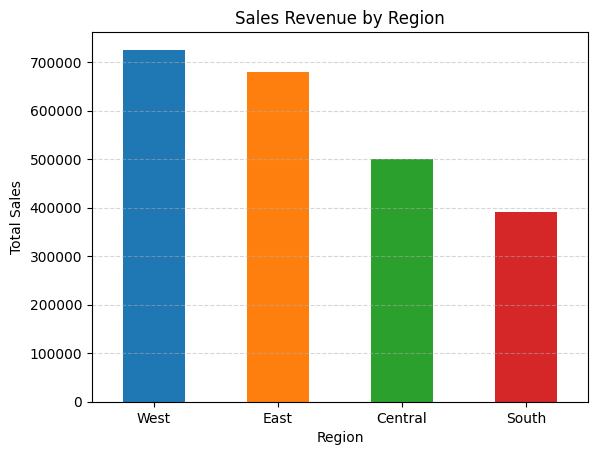

In [30]:
plt.figure(figsize=(8,5))

region_sales.plot(
    x='Region',
    y='Sales',
    kind='bar',
    color=['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728'],
    legend=False
)

plt.title('Sales Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Observation

The West region generated the highest sales revenue, followed by the East, Central and South regions. This indicates that the West region is the strongest contributor to the company's overall sales performance.


### Business Insight

The company should continue strengthening its presence in the highest-performing region while implementing targeted marketing and sales strategies to improve performance in lower-performing regions.

**Which States Generate the Highest Sales Revenue? (Top 10 States)**

In [31]:
# Calculate Top 10 States by Sales

top_states = (
    df.groupby('State')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

# Add Sales Contribution (%)
top_states['Sales Contribution (%)'] = (
    top_states['Sales'] / df['Sales'].sum() * 100
).round(2)

top_states

,State,Sales,Sales Contribution (%)
0,California,457687.6315,19.92
1,New York,310876.2710,13.53
2,Texas,170188.0458,7.41
3,Washington,138641.2700,6.04
4,Pennsylvania,116511.9140,5.07
5,Florida,89473.7080,3.89
6,Illinois,80166.1010,3.49
7,Ohio,78258.1360,3.41
8,Michigan,76269.6140,3.32
9,Virginia,70636.7200,3.07


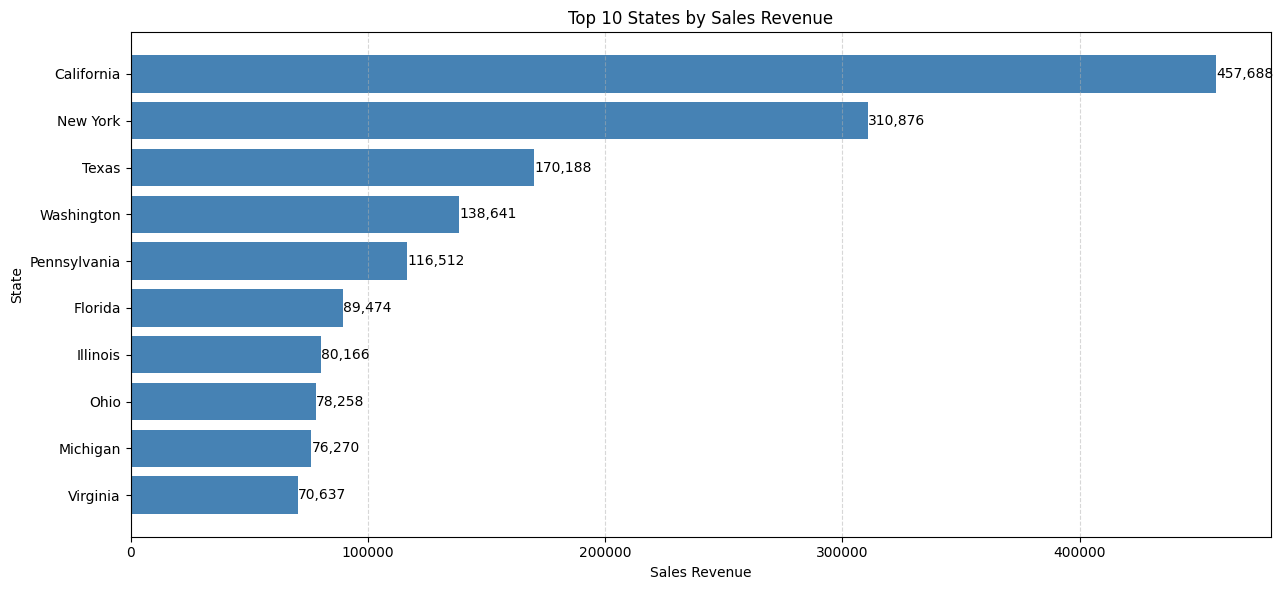

In [32]:
plt.figure(figsize=(13,6))

bars = plt.barh(
    top_states['State'],
    top_states['Sales'],
    color='steelblue'
)

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va='center',
        fontsize=10
    )

plt.title('Top 10 States by Sales Revenue')
plt.xlabel('Sales Revenue')
plt.ylabel('State')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### Observation

California generated the highest sales revenue among all states, followed by New York and Texas. This indicates that these states are the company's strongest markets and contribute significantly to overall business revenue.

### Business Insight

The company should continue strengthening its presence in high-performing states while identifying opportunities to increase sales in lower-performing states through targeted marketing campaigns and regional business strategies.

**How Does Discount Impact Profit?**

In [33]:
# Display Discount and Profit columns

discount_profit = df[['Discount', 'Profit']]
discount_profit.head()

,Discount,Profit
0,0.00,41.9136
1,0.00,219.5820
2,0.00,6.8714
3,0.45,-383.0310
4,0.20,2.5164


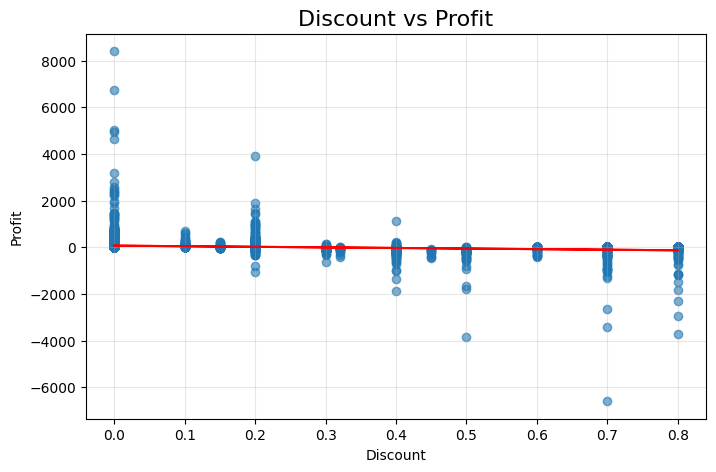

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(df['Discount'], df['Profit'], alpha=0.6)

z = np.polyfit(df['Discount'], df['Profit'], 1)
p = np.poly1d(z)

plt.plot(df['Discount'], p(df['Discount']), color='red')

plt.title('Discount vs Profit', fontsize=16)
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.grid(alpha=0.3)

plt.show()

### Observation

The scatter plot shows that higher discounts are generally associated with lower profits. While discounts may help increase sales, excessive discounting often reduces overall profitability and may even result in financial losses.

### Business Insight

The company should carefully manage discount strategies to balance sales growth and profitability. Offering discounts selectively rather than uniformly can help maximize profit while maintaining customer demand.

### Interpretation

The negative correlation indicates that as discounts increase, profit generally decreases. Although the relationship is not perfectly linear, excessive discounts tend to reduce profitability.

## **Conclusion**

This project analyzed the Superstore Sales dataset using Python by performing data cleaning, exploratory data analysis (EDA) and data visualization. The analysis identified important sales trends, top-performing product categories, regions, states and products while also examining the impact of discounts on profit.

The findings show that business performance varies across different categories and locations and that higher discounts can negatively affect profitability. Overall, this analysis demonstrates how data-driven insights can support better business decisions, improve sales strategies and optimize overall business performance.